# Sales Distribution Analysis

## Objective

Analyze the distribution of sales using statistical visualizations to understand:
- Sales distribution
- Data spread
- Skewness
- Outliers

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [4]:
sales_summary = df["Sales"].describe()

sales_summary

count    51289.000000
mean       156.430619
std         65.781574
min         33.000000
25%        109.000000
50%        159.000000
75%        218.000000
max        250.000000
Name: Sales, dtype: float64

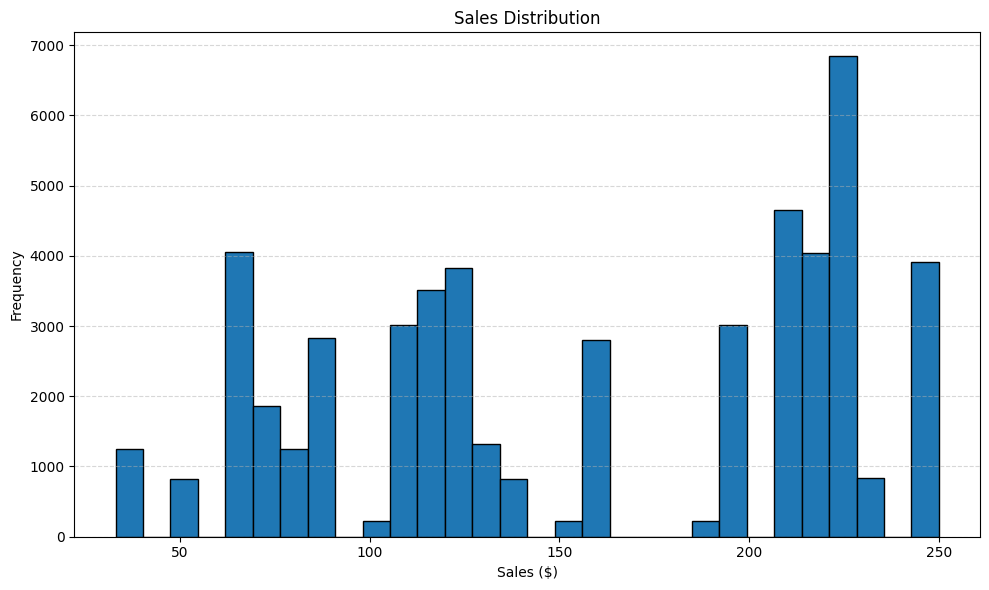

In [5]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Sales"],
    bins=30,
    edgecolor="black"
)

plt.title("Sales Distribution")

plt.xlabel("Sales ($)")

plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../charts/sales_histogram.png", dpi=300)

plt.show()

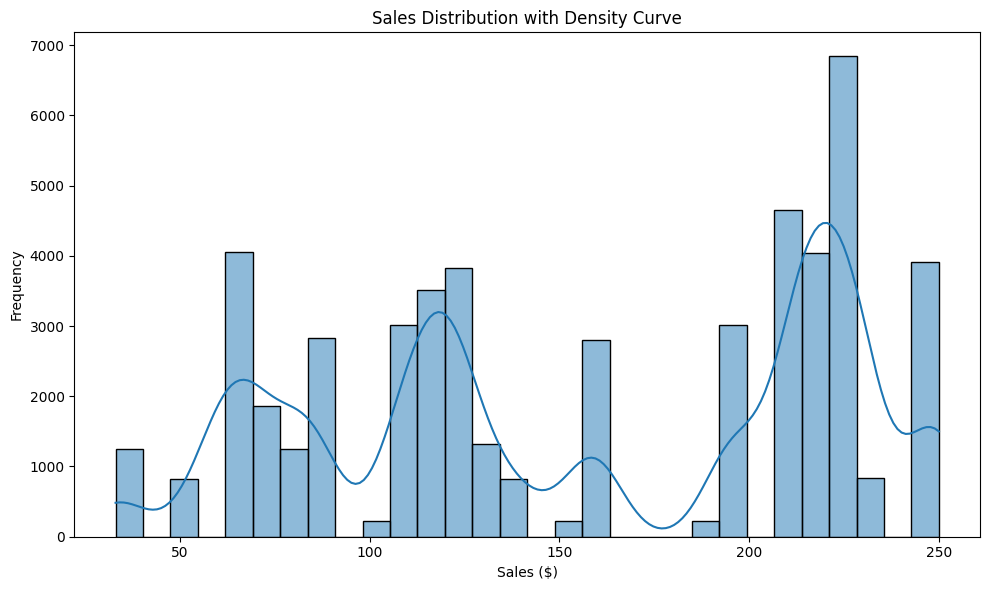

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution with Density Curve")

plt.xlabel("Sales ($)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../charts/sales_distribution_kde.png", dpi=300)

plt.show()

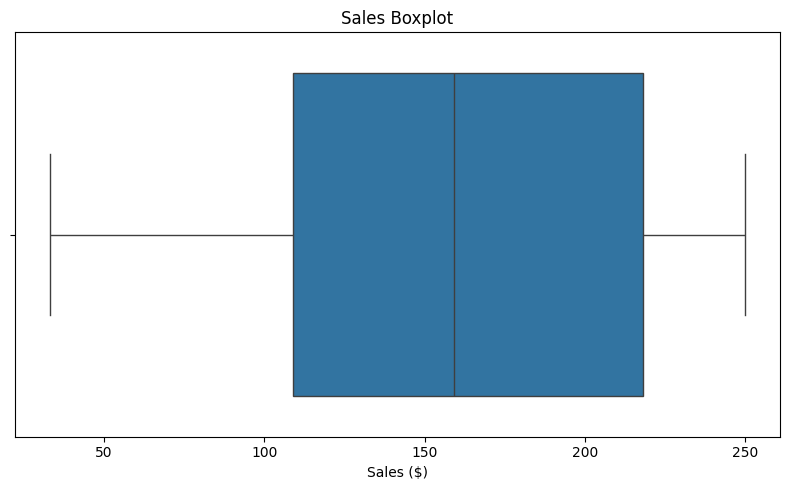

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Boxplot")

plt.xlabel("Sales ($)")

plt.tight_layout()

plt.savefig("../charts/sales_boxplot.png", dpi=300)

plt.show()

In [9]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print("Number of Outliers :", len(outliers))

Number of Outliers : 0


In [10]:
outliers[[
    "Order ID",
    "Customer Name",
    "Product",
    "Sales"
]].head(20)

,Order ID,Customer Name,Product,Sales


In [11]:
print("="*50)

print(f"Mean Sales   : ${df['Sales'].mean():,.2f}")

print(f"Median Sales : ${df['Sales'].median():,.2f}")

print(f"Minimum Sale : ${df['Sales'].min():,.2f}")

print(f"Maximum Sale : ${df['Sales'].max():,.2f}")

print(f"Standard Deviation : ${df['Sales'].std():,.2f}")

Mean Sales   : $156.43
Median Sales : $159.00
Minimum Sale : $33.00
Maximum Sale : $250.00
Standard Deviation : $65.78


## Business Insights

- Examined the distribution of sales using a histogram.
- Used a boxplot to detect outliers.
- Calculated descriptive statistics including mean, median, and standard deviation.
- Identified unusually high-value sales using the IQR method.

### Recommendations

- Investigate unusually large sales to understand purchasing patterns.
- Consider separate analysis for outliers if they significantly influence average sales.
- Use median along with mean when reporting sales performance.